
# Plot Cross-Validation Summaries for Multiple Experiments

This notebook:
- Loads multiple `summary_mean_std.json` files (each summarizing mean±std across folds for one experiment).
- Builds a tidy DataFrame across experiments.
- Plots **bar charts with error bars** (mean ± std) for each metric.
- Exports a combined CSV and a paper-ready **LaTeX table**.

> **How to use**: Edit the dictionary in **Cell 2** to point to your experiments.


In [ ]:

# === Cell 1: Imports & setup ===
import os, json, re
from pathlib import Path
from typing import Dict, Any, List, Optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# rendering setup
%matplotlib inline

# output directory for generated files (plots, CSV, LaTeX table)
OUT_DIR = Path('./plots_out')
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('Saving outputs to:', OUT_DIR.resolve())

# Load classification results
df = pd.read_csv("./results/final_recognition_results.csv")



In [ ]:

# Font and figure size variables
axis_label_fontsize = 20
tick_fontsize = 18
legend_fontsize = 14
legend_title_fontsize = 18
fig_width, fig_height = 7,7


sns.reset_orig()

# Normalize accuracy if it's in percentage
if df["accuracy"].max() > 1.0:
    df["accuracy"] /= 100.0

# Create combined legend label
df["model_modality"] = df["model"] + ": " + df["modality"]

# Melt metrics
df_melted = df.melt(
    id_vars=["model", "modality", "model_modality"],
    value_vars=["average_precision", "average_recall", "average_f1", "accuracy"],
    var_name="Metric",
    value_name="Score"
)

# Sort metric order
metric_order = ["average_precision", "average_recall", "average_f1", "accuracy"]
metric_title_map = {
    "average_precision": "Avg. Precision",
    "average_recall": "Avg. Recall",
    "average_f1": "Avg. F1-Score",
    "accuracy": "Top-1 Accuracy",
}

# Plot setup
plt.figure(figsize=(fig_width, fig_height))

# Plot each model_modality as a separate line
for name, group in df_melted.groupby("model_modality"):
    model = group["model"].iloc[0]
    modality = group["modality"].iloc[0]
    
    # Style logic
    ls = '-' if model == 'MTRSAP' else '--'
    marker = 'o' if model == 'MTRSAP' else 'X'
    color = None
    
    plt.plot(
        [metric_title_map[m] for m in group["Metric"]],
        group["Score"],
        label=name,
        linestyle=ls,
        marker=marker,
        color=color
    )

# Final touches
plt.ylabel("Score", fontsize=axis_label_fontsize)
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)

# Legend
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.2),
    ncol=2,
    frameon=False,
    fontsize=legend_fontsize,
    title='Model & Modality',
    title_fontsize=legend_title_fontsize
)

plt.tight_layout(rect=[0, 0, 1.8, 1])
plt.savefig(f'{OUT_DIR}/classification_results.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Assuming your dataframe is named 'df'
# df = pd.read_csv('your_file.csv')

# Prepare the data
metrics_to_plot = ['accuracy', 'average_f1']  # Focus on 2 key metrics
df_plot = df[['model', 'modality'] + metrics_to_plot].copy()

# Set up the plot
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Model Performance Across Modalities', fontsize=16, fontweight='bold', y=0.98)

models = df_plot['model'].unique()
modalities = df_plot['modality'].unique()
x = np.arange(len(modalities))
width = 0.35

colors = {'MTRSAP': '#2E86AB', 'MS-TCN++': '#A23B72', 'TCN': '#F18F01'}

# Plot each metric
for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    
    for i, model in enumerate(models):
        model_data = df_plot[df_plot['model'] == model]
        values = [model_data[model_data['modality'] == mod][metric].values[0] 
                  if mod in model_data['modality'].values else 0 
                  for mod in modalities]
        
        offset = width * (i - len(models)/2 + 0.5)
        bars = ax.bar(x + offset, values, width, label=model, 
                     color=colors[model], alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # Formatting
    ax.set_xlabel('Modality', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_title(f'{metric.replace("_", " ").title()} by Modality', 
                fontsize=13, fontweight='bold', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(modalities, rotation=45, ha='right', fontsize=9)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, 1)
    
    # Add value labels on bars (optional - remove if cluttered)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Focus on accuracy only for clearer visualization
fig, ax = plt.subplots(figsize=(14, 8))

models = df['model'].unique()
modalities = df['modality'].unique()
x = np.arange(len(modalities))
width = 0.4


for i, model in enumerate(models):
    model_data = df[df['model'] == model]
    values = [model_data[model_data['modality'] == mod]['accuracy'].values[0] 
              if mod in model_data['modality'].values else 0 
              for mod in modalities]
    
    offset = width * (i - 0.5)
    bars = ax.bar(x + offset, values, width, label=model, 
                 color=colors[model], alpha=0.85, edgecolor='black', linewidth=0.7)

ax.set_xlabel('Modality', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
# ax.set_title('Model Accuracy Comparison Across Modalities', fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(modalities, rotation=45, ha='right', fontsize=10)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_ylim(0, 1)
ax.axhline(y=0.5, color='red', linestyle=':', linewidth=1, alpha=0.5, label='Baseline')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Assuming your dataframe is named 'df'
# df = pd.read_csv('your_file.csv')

models = df['model'].unique()
modalities = df['modality'].unique()
x = np.arange(len(modalities))

# Bar parameters
bar_width = 0.35
edge_width = 1

# reset seaborn to fonts to default
sns.reset_orig()


# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Salmon pink and blue color scheme
colors = {'MTRSAP': 'skyblue', 'MS-TCN++': 'salmon', 'TCN': 'lightgreen'}

for i, model in enumerate(models):
    model_data = df[df['model'] == model]
    values = [model_data[model_data['modality'] == mod]['accuracy'].values[0] 
              if mod in model_data['modality'].values else 0 
              for mod in modalities]
    
    offset = bar_width * (i - 0.5)
    bars = ax.bar(x + offset, values, width=bar_width, label=model, 
                 color=colors[model], edgecolor='black', linewidth=edge_width)

# Y-axis
ax.set_ylabel('Accuracy', fontsize=16)
ax.tick_params(axis='y', labelsize=12)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_ylim(0, 1)

# X-axis
ax.set_xlabel('Modality', fontsize=16, labelpad=10)
ax.set_xticks(x)
ax.set_xticklabels(modalities, rotation=45, ha='right', fontsize=12)

# Remove top spine
ax.spines['top'].set_visible(False)

# Adjust x-limits
ax.set_xlim(-0.5, len(x) - 0.5)

# Legend
fig.legend(loc="upper right", bbox_to_anchor=(0.95, 0.98), fontsize=14)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/model_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create abbreviation mapping
modality_abbrev = {
    'Raven K': 'PSM',
    'Console K': 'MTM',
    'Console K (transformed)': 'MTM',
    'Console K (without grasper)': 'MTM-NG',
    'Console K (without grasper, transformed)': 'MTM-NG',
    'TrakStar K': 'TRAK',
    'TrakStar K (transformed)': 'TRAK',
    'Image (ResNet50)': 'IMG-R50',
    'Image (I3D)': 'IMG-I3D',
    'TrakStar + IMU': 'TRAK+IMU',
    'TrakStar + IMU + Images (ResNet50)': 'TRAK+IMU+R50',
    'TrakStar + IMU + Images (I3D)': 'TRAK+IMU+I3D',
    'Image': 'IMG',
    "TrakStar + IMU + Hand Keypoints": 'TRAK+IMU+HK'
}

ignore_modalities_list = ['Console K','Console K (without grasper)']

# Add abbreviated column
df['modality_abbrev'] = df['modality'].map(modality_abbrev)

models = df['model'].unique()

df = df[~df['modality'].isin(ignore_modalities_list)]

modalities_abbrev = df['modality_abbrev'].unique()



x = np.arange(len(modalities_abbrev))

bar_width = 0.30
edge_width = 1

fig, ax = plt.subplots(figsize=(10, 4))


for i, model in enumerate(models):
    model_data = df[df['model'] == model]
    values = [model_data[model_data['modality_abbrev'] == mod]['accuracy'].values[0] 
              if mod in model_data['modality_abbrev'].values else 0 
              for mod in modalities_abbrev]
    
    offset = bar_width * (i - 0.5)
    bars = ax.bar(x + offset, values, width=bar_width, label=model, 
                 color=colors[model], edgecolor='black', linewidth=edge_width)


ax.set_ylabel('Accuracy', fontsize=16)
ax.tick_params(axis='y', labelsize=12)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_ylim(0, 1)

ax.set_xlabel('Modality', fontsize=16, labelpad=10)
ax.set_xticks(x)
ax.set_xticklabels(modalities_abbrev, rotation=30, ha='center', fontsize=12)

ax.spines['top'].set_visible(False)
ax.set_xlim(-0.5, len(x) - 0.5)

fig.legend(loc="upper right", bbox_to_anchor=(0.95, 0.98), fontsize=14)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/model_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# Print legend for reference
print("\nModality Abbreviations:")
for full, abbrev in modality_abbrev.items():
    print(f"{abbrev}: {full}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


ignore_modalities_list = ['Console K','Console K (without grasper)']


# Add abbreviated column
df['modality_abbrev'] = df['modality'].map(modality_abbrev)

models = df['model'].unique()

df = df[~df['modality'].isin(ignore_modalities_list)]

modalities_abbrev = df['modality_abbrev'].unique()
x = np.arange(len(modalities_abbrev))

bar_width = 0.25
edge_width = 0.8


fig, ax = plt.subplots(figsize=(10, 5))


# Store bar containers for annotation
bar_containers = {}

for i, model in enumerate(models):
    model_data = df[df['model'] == model]
    values = [model_data[model_data['modality_abbrev'] == mod]['accuracy'].values[0] 
              if mod in model_data['modality_abbrev'].values else 0 
              for mod in modalities_abbrev]
    
    offset = bar_width * (i - 0.5)
    bars = ax.bar(x + offset, values, width=bar_width, label=model, 
                 color=colors[model], edgecolor='black', linewidth=edge_width)
    bar_containers[model] = (bars, values, offset)

# Add star annotations for key observations
# Define key modalities to highlight
highlights = {
    'MTM': {'model': 'MTRSAP', 'label': 'Best\nPerformer', 'color': 'darkblue'},
    'TRAK+IMU': {'model': 'MTRSAP', 'label': 'Promising\nMultimodal', 'color': 'darkgreen'}
}

for mod_abbrev, highlight_info in highlights.items():
    if mod_abbrev in modalities_abbrev:
        mod_idx = list(modalities_abbrev).index(mod_abbrev)
        model = highlight_info['model']
        
        if model in bar_containers:
            bars, values, offset = bar_containers[model]
            bar_height = values[mod_idx]
            
            # Add star above the bar
            ax.text(mod_idx + offset, bar_height + 0.01, '★', 
                   ha='center', va='bottom', fontsize=20, 
                   color=highlight_info['color'], fontweight='bold')
            
            # Add annotation text
            ax.text(mod_idx + offset, bar_height + 0.10, highlight_info['label'], 
                   ha='center', va='bottom', fontsize=11,
                   color=highlight_info['color'], fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=16)
ax.tick_params(axis='y', labelsize=12)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_ylim(0, 1.05)  # Increased to accommodate annotations

ax.set_xlabel('Modality', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(modalities_abbrev, rotation=30, ha='right', fontsize=12, rotation_mode='anchor')

ax.spines['top'].set_visible(False)
ax.set_xlim(-0.4, len(x) - 0.4)

fig.legend(loc="upper right", bbox_to_anchor=(0.98, 0.98), fontsize=14)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


# Print legend for reference
print("\nModality Abbreviations:")
for full, abbrev in modality_abbrev.items():
    print(f"{abbrev}: {full}")

# Confusion Matrix

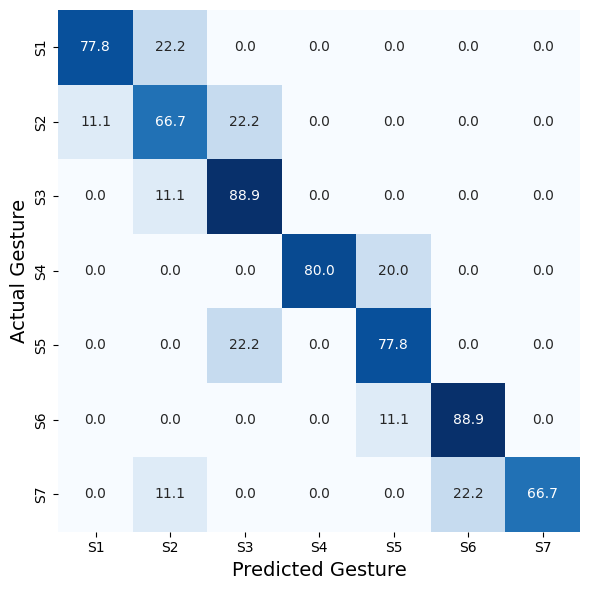

In [119]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

confusion_matrix_csv = './results/job_MTRSAP_1761053585/trakstar_sw_left_sw_right_10hz/confusion_matrix_labeled_epoch_final.csv'

class_mapping = {
    'Class 0': "S1",
    'Class 1': "S2",
    'Class 2': "S3",
    'Class 3': "S4",
    'Class 4': "S5",
    'Class 5': "S6",
    'Class 6': "S7"
}

# Load confusion matrix with first column as index
cm_df = pd.read_csv(confusion_matrix_csv, index_col=0)

# Rename index and columns using the mapping
cm_df.rename(index=class_mapping, columns=class_mapping, inplace=True)

# convert numbers to percentages
cm_df = cm_df.div(cm_df.sum(axis=1), axis=0) * 100

plt.figure(figsize=(6, 6))
sns.heatmap(cm_df, annot=True, fmt='.1f', cmap='Blues', cbar=False,
            xticklabels=cm_df.columns, yticklabels=cm_df.index)

# increase font size for ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('Predicted Gesture', fontsize=14)
plt.ylabel('Actual Gesture', fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/confusion_matrix.png', dpi=300)

plt.show()